# Install Required Libraries

This project requires several NLP and machine learning libraries.

sentence-transformers → to create text embeddings  
faiss → fast similarity search  
transformers → to build RAG model  
wordcloud → visualization

In [1]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install transformers
!pip install wordcloud
!pip install kaggle

# Import Libraries

We import libraries used for data processing, visualization, embeddings,
vector search, and the RAG pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sentence_transformers import SentenceTransformer

import faiss

from wordcloud import WordCloud

from sklearn.decomposition import PCA

from transformers import pipeline

# Load Dataset

The dataset contains Flipkart product reviews including product name,
review text, summary, and rating.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Dataset-SA.csv to Dataset-SA.csv


# Read Dataset

Load dataset into pandas dataframe and inspect structure.

In [4]:
df = pd.read_csv("Dataset-SA.csv")

df.head()

,product_name,product_price,Rating,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [5]:
print(df.columns)

Index(['product_name', 'product_price', 'Rating', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')


# Text Cleaning

Clean review text by removing punctuation, numbers, and converting to lowercase.

In [6]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

# Combine Review and Summary

Combining text fields improves semantic understanding.

In [7]:
df["text"] = df["Review"].astype(str) + " " + df["Summary"].astype(str)

df["text"] = df["text"].apply(clean_text)

df.head()

,product_name,product_price,Rating,Review,Summary,Sentiment,text
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super great cooler excellent air flow and for ...
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome best budget fit cooler nice cooling
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair the quality is good but the power of air ...
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product very bad product its a only a fan
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair ok ok product


In [8]:
df = df.dropna(subset=["text"])

df.reset_index(drop=True, inplace=True)

# Rating Distribution

This shows how customer ratings are distributed.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


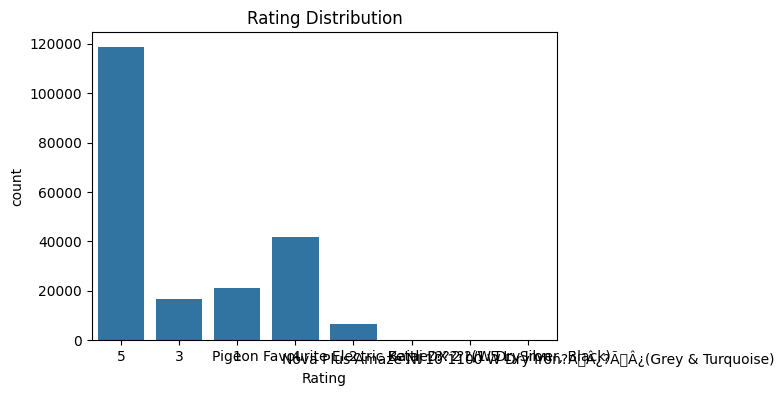

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Rating", data=df)

plt.title("Rating Distribution")

plt.show()

# Word Cloud Visualization

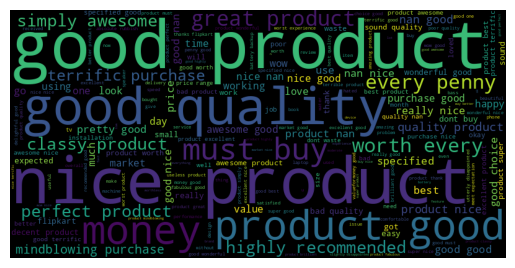

In [10]:
text_data = " ".join(df["text"].tolist())

wordcloud = WordCloud(width=800,height=400).generate(text_data)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

# Sentence Embeddings

We use Sentence Transformers to convert text into dense vectors.

In [11]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/6408 [00:00<?, ?it/s]

# FAISS Vector Index

Normalize embeddings first, then add them to the FAISS index.

In [12]:
dimension = embeddings.shape[1]

embeddings_normalized = embeddings.copy()

faiss.normalize_L2(embeddings_normalized)

index = faiss.IndexFlatIP(dimension)

index.add(embeddings_normalized)

# Semantic Search Function

This function retrieves the most relevant reviews based on semantic similarity.

In [13]:
def semantic_search(query, k=5):

    query_embedding = model.encode([query])

    faiss.normalize_L2(query_embedding)

    scores, indices = index.search(query_embedding, k)

    results = df.iloc[indices[0]][["product_name","text","Rating"]]

    return results

In [14]:
semantic_search("battery life is good",5)

,product_name,text,Rating
118402,"boAt Wave Neo with 1.69 inch , 2.5D Curved Dis...",very good battery life is good,4
118135,"boAt Wave Neo with 1.69 inch , 2.5D Curved Dis...",must buy good product battery life is good,5
84014,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,excellent long battery life worth buying,5
116841,"Noise ColorFit Icon 2 1.8 Display, Bluetooth C...",just wow good battery life and worth of cost,5
5493,F FERONS Wireless rechargeable portable Premiu...,awesome quality better but battery life low,5


# PCA Visualization of Embeddings

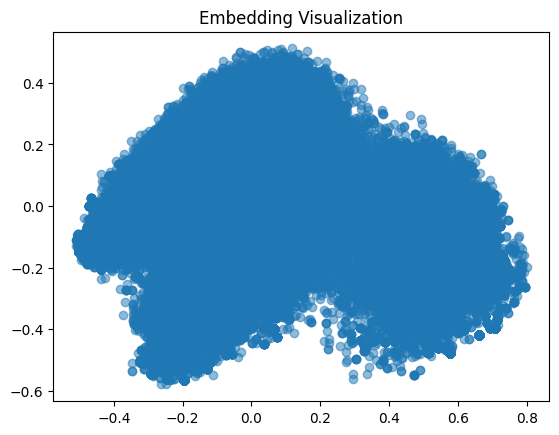

In [15]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1], alpha=0.5)

plt.title("Embedding Visualization")

plt.show()

# RAG Pipeline

We use FLAN-T5 to generate natural language answers using retrieved documents.

In [16]:
generator = pipeline(
    "text-generation",
    model="google/flan-t5-base"
)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

In [17]:
def rag_answer(query):

    docs = semantic_search(query,3)

    context = " ".join(docs["text"].tolist())[:2000]

    prompt = f"""
    Answer the question based on the context.

    Context:
    {context}

    Question:
    {query}

    Answer:
    """

    result = generator(prompt, max_length=200)

    return result[0]["generated_text"]

In [18]:
rag_answer("Is the battery life good?")

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'\n    Answer the question based on the context.\n\n    Context:\n    very good battery life is good excellent long battery life worth buying must buy good product battery life is good\n\n    Question:\n    Is the battery life good?\n\n    Answer:\n    or short lifespan lifetime times than would see even today-time hours—over'

# Evaluation Metrics

We evaluate the search system using Precision@K and Recall@K.

In [ ]:
def precision_at_k(query, k=5):

    results = semantic_search(query,k)

    relevant = results["text"].str.contains(query.lower()).sum()

    return relevant/k

In [20]:
queries = [
    "battery life",
    "camera quality",
    "good sound",
    "fast charging"
]

for q in queries:

    print(q, precision_at_k(q,5))

battery life 0.8
camera quality 0.6
good sound 1.0
fast charging 0.4
